# pig-math Stage 1: Broad-dataset Digit Classifier

訓練本機 OCR base model（取代 `mnist_transfer_cnn_v1`），把兒童手寫辨識率從 50% 拉到 65-75%。

**詳見** `docs/plans/2026-05-11-handwriting-finetune-broad-dataset.md`。

## 用法（VS Code + Colab extension）

1. VS Code 開此 `.ipynb`
2. 右上「選取核心」→ **Colab** → 選 **T4 GPU**
3. 登入 Google 帳號
4. **Run All** 或一格一格跑
5. 最後一格自動下載 `pig-math-tfjs-model.zip`，丟給 Claude 接後續

## 訓練資料（~360k 樣本，自動下載）

| Dataset | 樣本數 | Source |
|---|---|---|
| MNIST | 70k | `tf.keras.datasets.mnist` |
| EMNIST digits | 280k | `tensorflow_datasets` |
| USPS | 9.3k | HuggingFace `flwrlabs/usps` |

## 預計時間

T4 GPU 30-60 分鐘。

## 1. Install deps

In [3]:
# tfjs 4.22+ import chain 強行載入 tensorflow_decision_forests（converter.py → tf_saved_model_conversion_v2.py）
# 但裝 tfdf 會把 TF 從 Colab 預裝的 2.20 降到 2.19，跟 tensorflow-text / ydf-tf 二進位衝突。
# 我們是 plain Keras CNN 完全不用 decision forests，stub 一個假 tfdf module 騙過 import chain。
#
# 順序很重要：sys.modules stub 必須在 `import tensorflowjs` 之前；`!pip install` 是 subprocess
# 不影響 stub。

# Step 1: stub tfdf
import sys, types
sys.modules['tensorflow_decision_forests'] = types.ModuleType('tensorflow_decision_forests')

# Step 2: 裝 tfjs（--no-deps 不裝 tfdf）+ HF datasets（USPS 用）
!pip install -q --no-deps --upgrade tensorflowjs
!pip install -q datasets

# Step 3: 確認版本（stub 後 tfjs import chain 不再 trigger tfdf）
import tensorflow as tf
import tensorflowjs as tfjs
print(f"TF {tf.__version__} (要 2.18+ 跟 Colab 預裝 2.20)，tfjs {tfjs.__version__} (要 4.22+)")
assert tuple(int(x) for x in tf.__version__.split('.')[:2]) >= (2, 18), "TF 版本太低"
assert tuple(int(x) for x in tfjs.__version__.split('.')[:2]) >= (4, 22), "tfjs 版本太低"

TF 2.20.0 (要 2.18+ 跟 Colab 預裝 2.20)，tfjs 4.22.0 (要 4.22+)


In [4]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.metrics import classification_report, confusion_matrix

tf.keras.utils.set_random_seed(42)
print(f"TF version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TF version: 2.20.0
GPU available: True


## 2. 載入 + 統一資料集

所有樣本統一成 **黑底白字 28×28 uint8**（背景 0、字 255）。

**為何是黑底白字？** worksheet inference 時 `preprocessDigit` 內部會做 `sub(255, x)` 把 PadView 產的白底黑字翻成黑底白字再送 model。所以**訓練資料必須跟那一刻一致**才能對齊 distribution。MNIST/EMNIST raw 本來就是黑底白字（直接用），USPS 動態偵測。

In [5]:
# 全部統一成「黑底白字 uint8 [0,255]」，與 worksheet preprocessDigit 內部 sub(255) 後一致

# --- MNIST: 70k, 28x28 黑底白字（raw, mean 應 ~33） ---
(mx_tr, my_tr), (mx_te, my_te) = tf.keras.datasets.mnist.load_data()
print(f"MNIST   train={mx_tr.shape} test={mx_te.shape}  mean={mx_tr.mean():.1f} (應 < 128 = 黑底)")
assert mx_tr.mean() < 128, "MNIST 不是黑底白字，pipeline 假設錯了"

# --- EMNIST digits: 280k, 28x28 黑底白字 ---
# 注意：tfds 載入的 EMNIST 是 transposed（NIST 原始 column-major），必須翻回 row-major
# https://www.tensorflow.org/datasets/catalog/emnist
ds_tr, ds_te = tfds.load("emnist/digits", split=["train", "test"], as_supervised=True, batch_size=-1)
ex_tr, ey_tr = tfds.as_numpy(ds_tr); ex_te, ey_te = tfds.as_numpy(ds_te)
ex_tr = np.transpose(ex_tr.squeeze(-1), (0, 2, 1))  # un-transpose
ex_te = np.transpose(ex_te.squeeze(-1), (0, 2, 1))
print(f"EMNIST  train={ex_tr.shape} test={ex_te.shape}  mean={ex_tr.mean():.1f} (應 < 128 = 黑底)")
assert ex_tr.mean() < 128, "EMNIST 不是黑底白字"

# --- USPS: 9k, 16x16 → resize 28x28，動態偵測 polarity ---
from datasets import load_dataset
usps = load_dataset("flwrlabs/usps")

def _stack(split):
    imgs, lbls = [], []
    for row in usps[split]:
        img = np.array(row["image"])
        if img.ndim == 3:
            img = img[..., 0]
        imgs.append(img); lbls.append(row["label"])
    return np.stack(imgs), np.array(lbls, dtype=np.int64)

ux_tr_raw, uy_tr = _stack("train"); ux_te_raw, uy_te = _stack("test")

# USPS HF polarity 動態偵測：mean > 128 = 白底黑字 → 反色成黑底白字
sample_mean = ux_tr_raw[:200].mean()
if sample_mean > 128:
    print(f"USPS raw mean={sample_mean:.1f} > 128 → 偵測為白底黑字，反色成黑底白字")
    ux_tr_raw = 255 - ux_tr_raw
    ux_te_raw = 255 - ux_te_raw
else:
    print(f"USPS raw mean={sample_mean:.1f} < 128 → 已是黑底白字（與 MNIST 同）")

def _resize_28(imgs):
    t = tf.image.resize(imgs[..., None].astype(np.float32), [28, 28], method="bilinear")
    return tf.cast(t[..., 0], tf.uint8).numpy()

ux_tr = _resize_28(ux_tr_raw); ux_te = _resize_28(ux_te_raw)
print(f"USPS    train={ux_tr.shape} test={ux_te.shape}  mean={ux_tr.mean():.1f} (應 < 128 = 黑底)")
assert ux_tr.mean() < 128, "USPS 反色後仍非黑底白字，polarity 偵測壞了"

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MNIST   train=(60000, 28, 28) test=(10000, 28, 28)  mean=33.3 (應 < 128 = 黑底)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

...

data/train-00000-of-00001.parquet:   0%|          | 0.00/2.00M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/559k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7291 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2007 [00:00<?, ? examples/s]

USPS raw mean=67.9 < 128 → 已是黑底白字（與 MNIST 同）
USPS    train=(7291, 28, 28) test=(2007, 28, 28)  mean=62.6 (應 < 128 = 黑底)


In [6]:
# --- Concat 全部 ---
x_train = np.concatenate([mx_tr, ex_tr, ux_tr], axis=0)
y_train = np.concatenate([my_tr.astype(np.int64), ey_tr.astype(np.int64), uy_tr], axis=0)
x_test  = np.concatenate([mx_te, ex_te, ux_te], axis=0)
y_test  = np.concatenate([my_te.astype(np.int64), ey_te.astype(np.int64), uy_te], axis=0)
print(f"COMBINED  train={x_train.shape} test={x_test.shape}")

# uint8 → float32 [0,1] + add channel dim
x_train = x_train.astype(np.float32)[..., None] / 255.0
x_test  = x_test.astype(np.float32)[..., None] / 255.0

COMBINED  train=(307291, 28, 28) test=(52007, 28, 28)


### Sanity check：隨機看幾張統一後的圖（應該白底黑字）

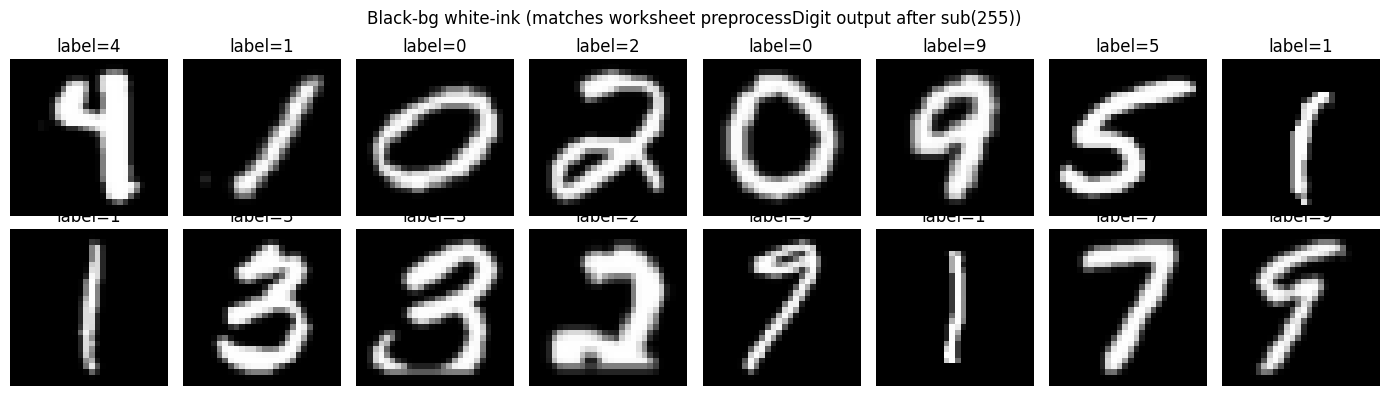

x_train mean = 0.167 (應 ~0.1-0.15 = 黑底)
x_train min/max = 0.00 / 1.00


In [7]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for ax in axes.flat:
    idx = np.random.randint(len(x_train))
    ax.imshow(x_train[idx, ..., 0], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"label={y_train[idx]}")
    ax.axis("off")
plt.suptitle("Black-bg white-ink (matches worksheet preprocessDigit output after sub(255))")
plt.tight_layout(); plt.show()

# Polarity 最終確認
print(f"x_train mean = {x_train.mean():.3f} (應 ~0.1-0.15 = 黑底)")
print(f"x_train min/max = {x_train.min():.2f} / {x_train.max():.2f}")

## 3. 建 model + augmenter

對齊 `mnist_transfer_cnn_v1` 經典 Keras MNIST CNN（~600k params）。

In [8]:
def build_model(num_classes=10):
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
        tf.keras.layers.Conv2D(32, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(2),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
        tf.keras.layers.Conv2D(64, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(2),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ], name="pig_math_digit_v1")

model = build_model()
model.summary()

Model: "pig_math_digit_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271,210 (1.03 MB)

 Trainable params: 271,210 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# augmenter — 黑底白字所以 fill_value=0.0（黑色填補旋轉/平移留白）
augmenter = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(10/360, fill_mode="constant", fill_value=0.0),
    tf.keras.layers.RandomTranslation(0.08, 0.08, fill_mode="constant", fill_value=0.0),
    tf.keras.layers.RandomZoom(0.08, fill_mode="constant", fill_value=0.0),
], name="augmenter")

def _augment(x, y):
    return augmenter(x, training=True), y

train_ds = (tf.data.Dataset.from_tensor_slices((x_train, y_train))
            .shuffle(20000, seed=42).batch(128)
            .map(_augment, num_parallel_calls=tf.data.AUTOTUNE)
            .prefetch(tf.data.AUTOTUNE))
val_ds = (tf.data.Dataset.from_tensor_slices((x_test, y_test))
          .batch(128).prefetch(tf.data.AUTOTUNE))

## 4. 訓練

T4 GPU 約 30-60 分鐘。EarlyStopping 在 val_accuracy 卡 3 epoch 不進步就停。

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

history = model.fit(
    train_ds, validation_data=val_ds, epochs=20, verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
    ],
)

Epoch 1/20
2401/2401 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - accuracy: 0.9518 - loss: 0.1589 - val_accuracy: 0.9913 - val_loss: 0.0303 - learning_rate: 0.0010
Epoch 2/20
2401/2401 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - accuracy: 0.9842 - loss: 0.0565 - val_accuracy: 0.9942 - val_loss: 0.0201 - learning_rate: 0.0010
Epoch 3/20
2401/2401 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - accuracy: 0.9876 - loss: 0.0452 - val_accuracy: 0.9946 - val_loss: 0.0200 - learning_rate: 0.0010
Epoch 4/20
2401/2401 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - accuracy: 0.9894 - loss: 0.0395 - val_accuracy: 0.9958 - val_loss: 0.0184 - learning_rate: 0.0010
Epoch 5/20
2401/2401 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - accuracy: 0.9906 - loss: 0.0355 - val_accuracy: 0.9954 - val_loss: 0.0191 - learning_rate: 0.0010
Epoch 6/20
2401/2401 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - accuracy: 0.9910 - loss: 0.0340 - val_accuracy: 0.9962 - val_loss: 0.0159 - learning_rate: 0.0010
Epoch 7/20
2401/2401 ━━━━━━━━━━━━━━━━━━━━ 30s 12ms/step - accura

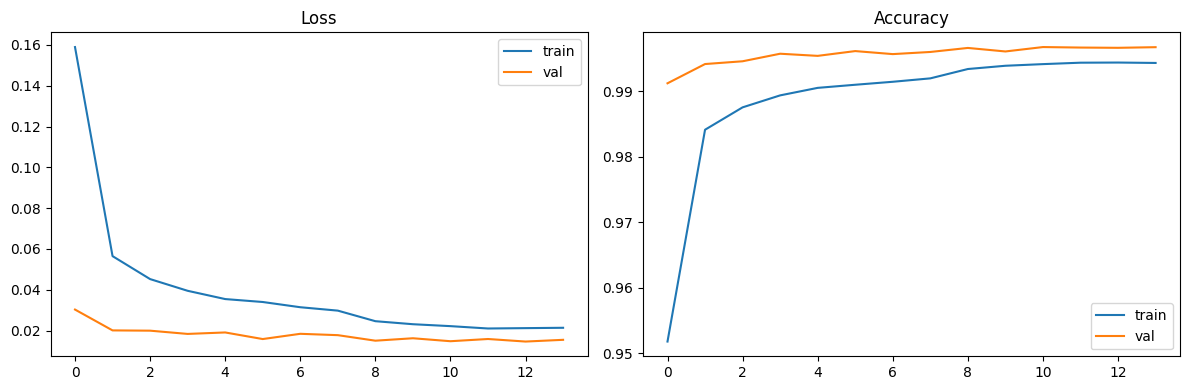

In [11]:
# Training curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history["loss"], label="train")
ax1.plot(history.history["val_loss"], label="val")
ax1.set_title("Loss"); ax1.legend()
ax2.plot(history.history["accuracy"], label="train")
ax2.plot(history.history["val_accuracy"], label="val")
ax2.set_title("Accuracy"); ax2.legend()
plt.tight_layout(); plt.show()

## 5. 評估 + Confusion matrix

**主要關注 6 / 8 / 9 / 0 → 3 的誤判率**（pig-math 50% 主訴的 domain gap）。目標 < 5%。

In [12]:
val_loss, val_acc = model.evaluate(val_ds, verbose=0)
print(f"Overall val_acc = {val_acc:.4f} (loss={val_loss:.4f})")

y_pred = model.predict(x_test, batch_size=256, verbose=0).argmax(-1)
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion matrix (rows=true, cols=pred):")
print("      " + "  ".join(f"{i:>5d}" for i in range(10)))
for i, row in enumerate(cm):
    print(f"{i:>3d}: " + "  ".join(f"{v:>5d}" for v in row))

print("\nPer-class report:")
print(classification_report(y_test, y_pred, digits=4))

print("--- pig-math 主訴: 圓圈型字 → 3 誤判率 ---")
for src in [6, 8, 9, 0]:
    pct = 100 * cm[src, 3] / cm[src].sum()
    mark = "✓" if pct < 5.0 else "⚠️"
    print(f"  {mark} Class {src} → 3: {cm[src,3]}/{cm[src].sum()} ({pct:.1f}%)")

Overall val_acc = 0.9968 (loss=0.0148)

Confusion matrix (rows=true, cols=pred):
          0      1      2      3      4      5      6      7      8      9
  0:  5326      1      2      0      1      1      0      3      4      1
  1:     4   5378      2      0      2      0      5      6      2      0
  2:     0      1   5216      3      1      1      0      3      4      1
  3:     0      0      4   5163      0      6      0      0      2      1
  4:     0      1      0      0   5167      1      1      2      2      8
  5:     2      0      1     12      0   5034      2      0      1      0
  6:     9      0      2      0      2      4   5104      0      7      0
  7:     0      2     11      3      2      0      0   5155      0      2
  8:     2      1      0      2      1      2      1      0   5129      2
  9:     1      0      0      1      5      3      0      4      4   5168

Per-class report:
              precision    recall  f1-score   support

           0     0.9966    0.9

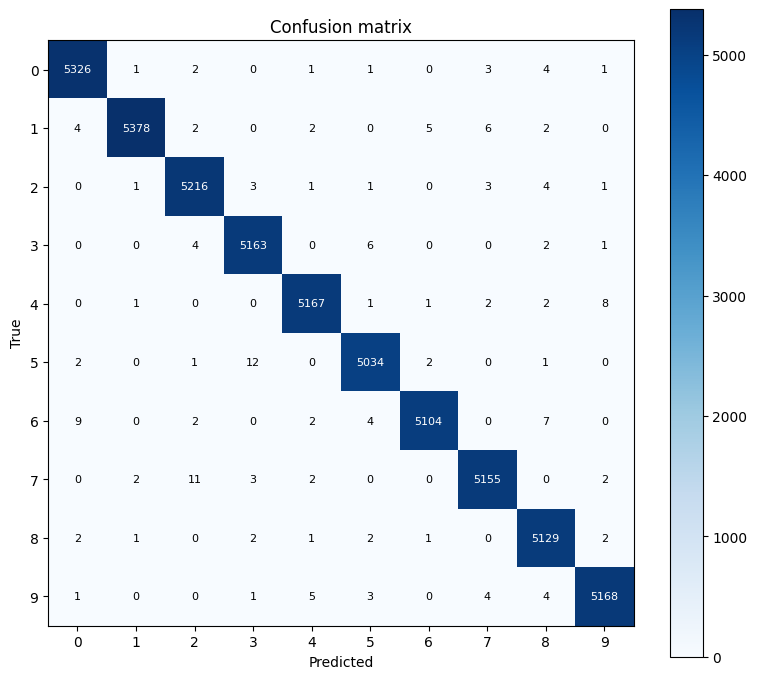

In [13]:
# 視覺化 confusion matrix
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=8)
plt.colorbar(im); plt.tight_layout(); plt.show()

## 6. Export TF.js layers format

輸出 `./tfjs-model/`，含 `model.json` + `group1-shard*.bin`，直接相容 worksheet 的 `tf.loadLayersModel`。

In [14]:
import tensorflowjs as tfjs

out = Path("./tfjs-model")
out.mkdir(parents=True, exist_ok=True)
tfjs.converters.save_keras_model(model, str(out))

manifest = {
    "version": "v1-broad-stage1",
    "val_acc": float(val_acc),
    "val_loss": float(val_loss),
    "training_samples": int(len(x_train)),
    "validation_samples": int(len(x_test)),
    "datasets": ["mnist", "emnist_digits", "usps"],
    "epochs_trained": len(history.history["loss"]),
    "confusion_6_to_3_pct": float(100 * cm[6, 3] / cm[6].sum()),
    "confusion_8_to_3_pct": float(100 * cm[8, 3] / cm[8].sum()),
    "confusion_9_to_3_pct": float(100 * cm[9, 3] / cm[9].sum()),
    "confusion_0_to_3_pct": float(100 * cm[0, 3] / cm[0].sum()),
}
(out / "training-manifest.json").write_text(json.dumps(manifest, indent=2))

print("Files in tfjs-model/:")
for f in sorted(out.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size/1024:.1f} KB)")

failed to lookup keras version from the file,
    this is likely a weight only file
Files in tfjs-model/:
  group1-shard1of1.bin  (1059.4 KB)
  model.json  (8.1 KB)
  training-manifest.json  (0.4 KB)


## 7. 下載 zip

若在 **Colab runtime**（含 VS Code Colab extension），會觸發瀏覽器下載。否則檔案留在 `./tfjs-model/`，自行從檔案總管拿。

In [16]:
import shutil
shutil.make_archive("pig-math-tfjs-model", "zip", "tfjs-model")
print("Zipped: pig-math-tfjs-model.zip")

# 嘗試 google.colab.files.download（網頁 Colab 用）— VS Code Colab extension 不支援，會 fallback
try:
    from google.colab import files
    files.download("pig-math-tfjs-model.zip")
    print("✓ 觸發 files.download")
except Exception as e:
    print(f"files.download 失敗（{type(e).__name__}），用下方 HTML link 下載")

# Fallback：data URI HTML download link（VS Code Notebook 能 render <a download>）
from IPython.display import HTML, display
import base64, os

zip_path = "pig-math-tfjs-model.zip"
size_kb = os.path.getsize(zip_path) / 1024
with open(zip_path, "rb") as f:
    b64 = base64.b64encode(f.read()).decode()

display(HTML(f'''
<div style="padding:20px;background:#f0f0f0;border-radius:8px;text-align:center;">
  <p style="margin:0 0 12px 0;font-size:14px;color:#333;">
    ✓ 訓練完成，可下載 model（{size_kb:.0f} KB）
  </p>
  <a href="data:application/zip;base64,{b64}"
     download="pig-math-tfjs-model.zip"
     style="display:inline-block;padding:12px 24px;background:#7B61FF;
            color:white;text-decoration:none;border-radius:6px;
            font-weight:bold;font-size:16px;">
    📥 下載 pig-math-tfjs-model.zip
  </a>
</div>
'''))

Zipped: pig-math-tfjs-model.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ 觸發 files.download
